# POPLAR + OAK Data Exploration

Supplementary data from Gandara et al., *Nature Medicine* 2018 ([10.1038/s41591-018-0134-x](https://doi.org/10.1038/s41591-018-0134-x)) — blood tumor mutational burden (bTMB) as a predictive biomarker for atezolizumab vs docetaxel in 2L+ NSCLC.

**Trials**
- **POPLAR** (NCT01903993): phase 2, n≈287, Fehrenbacher et al. *Lancet* 2016
- **OAK** (NCT02008227): phase 3, n≈1225, Rittmeyer et al. *Lancet* 2017

Both: atezolizumab (anti-PD-L1) vs docetaxel in 2L+ advanced NSCLC. OAK median OS 13.8 vs 9.6 mo, HR 0.73.

**Key columns**
- `btmb` — blood tumor mutational burden (integer count of somatic variants on the assay panel)
- `BEP` — biomarker-evaluable population flag (Y/N); subset with enough cfDNA / coverage for a reliable bTMB call
- `TRT01P` — treatment arm (Atezolizumab or Docetaxel)
- `OS` / `OS.CNSR` — overall survival (months) and censor indicator (1 = censored, 0 = event)
- `PFS` / `PFS.CNSR` — progression-free survival analog
- `BCOR` — best confirmed response (CR/PR/SD/PD/NE)
- `TC*IC*` (OAK only) — PD-L1 IHC thresholds on tumor cells / immune cells

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)

XLSX = "41591_2018_134_MOESM3_ESM.xlsx"
xl = pd.ExcelFile(XLSX)
xl.sheet_names

['OAK_POPLAR_btmb_variants', 'POPLAR_Clinical_Data', 'OAK_Clinical_Data']

## Load clinical data

The sheets have a header row at row 0 plus a `.`-as-missing convention. Normalize to NaN and coerce numerics.

In [2]:
def load_clinical(sheet, trial):
    df = pd.read_excel(XLSX, sheet_name=sheet)
    df = df.replace({".": np.nan})
    df["Trial"] = trial
    for col in ["cfDNA_Input_ng", "cfDNA_input_ng", "MSAF", "Median_exon_coverage",
                "btmb", "BAGE", "ECOGGR", "blSLD", "METSITES",
                "PFS", "PFS.CNSR", "OS", "OS.CNSR"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.rename(columns={"cfDNA_input_ng": "cfDNA_Input_ng",
                            "btmb_QC": "QC_Status",
                            "PRIORTXC": "PRIORTX",
                            "EMLAMUT": "EML4MUT"})
    # 'MPDL3280A' is atezolizumab's development codename — normalize to the marketed name.
    df["TRT01P"] = df["TRT01P"].replace({"MPDL3280A": "Atezolizumab"})
    return df

poplar = load_clinical("POPLAR_Clinical_Data", "POPLAR")
oak    = load_clinical("OAK_Clinical_Data",    "OAK")
variants = pd.read_excel(XLSX, sheet_name="OAK_POPLAR_btmb_variants")

print(f"POPLAR: {poplar.shape}")
print(f"OAK:    {oak.shape}")
print(f"Variants: {variants.shape}")

shared_cols = [c for c in poplar.columns if c in oak.columns]
clinical = pd.concat([poplar[shared_cols], oak[shared_cols]], ignore_index=True)
print(f"Combined clinical (shared cols): {clinical.shape}")


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/2f/hn0bzd4x1sn1m0w5_cn7mm5r0000gn/T/ipykernel_98378/197409400.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({".": np.nan})


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/2f/hn0bzd4x1sn1m0w5_cn7mm5r0000gn/T/ipykernel_98378/197409400.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({".": np.nan})


POPLAR: (287, 26)
OAK:    (850, 28)
Variants: (12022, 17)
Combined clinical (shared cols): (1137, 26)


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
# Cohort sizes by trial × treatment arm × BEP
pd.crosstab([clinical["Trial"], clinical["BEP"]], clinical["TRT01P"], margins=True)

TRT01P      Atezolizumab  Docetaxel   All
Trial  BEP                               
OAK    N             101        107   208
       Y             324        318   642
POPLAR N              39         37    76
       Y             105        106   211
All                  569        568  1137

In [4]:
# Missingness per column (combined)
miss = clinical.isna().mean().sort_values(ascending=False).to_frame("pct_missing")
miss["pct_missing"] = (miss["pct_missing"] * 100).round(1)
miss

,pct_missing
KRASMUT,70.6
EML4MUT,52.1
btmb,25.0
EGFRMUT,22.7
BCOR,9.3
MSAF,9.0
Median_exon_coverage,6.6
QC_Status,6.6
cfDNA_Input_ng,6.6
blSLD,0.1


## Baseline characteristics by trial and arm

In [5]:
def summarize(g):
    return pd.Series({
        "N": len(g),
        "Age median": g["BAGE"].median(),
        "% Male": (g["SEX"] == "M").mean() * 100,
        "% Non-squamous": (g["HIST"] == "NON-SQUAMOUS").mean() * 100,
        "% ECOG 1": (g["ECOGGR"] == 1).mean() * 100,
        "% Current/Previous smoker": g["TOBHX"].isin(["CURRENT", "PREVIOUS"]).mean() * 100,
        "bTMB median (BEP)": g.loc[g["BEP"] == "Y", "btmb"].median(),
        "OS median (mo)": g["OS"].median(),
        "OS events": int((g["OS.CNSR"] == 0).sum()),
    })

clinical.groupby(["Trial", "TRT01P"]).apply(summarize, include_groups=False).round(1)

N  Age median  % Male  % Non-squamous  % ECOG 1  \
Trial  TRT01P                                                              
OAK    Atezolizumab  425.0        63.0    61.4            73.6      63.5   
       Docetaxel     425.0        64.0    60.9            74.1      62.4   
POPLAR Atezolizumab  144.0        62.0    64.6            66.0      66.7   
       Docetaxel     143.0        62.0    53.1            66.4      67.8   

                     % Current/Previous smoker  bTMB median (BEP)  \
Trial  TRT01P                                                       
OAK    Atezolizumab                       80.2                7.5   
       Docetaxel                          83.1                7.0   
POPLAR Atezolizumab                       81.2                8.0   
       Docetaxel                          79.7                9.0   

                     OS median (mo)  OS events  
Trial  TRT01P                                   
OAK    Atezolizumab            12.6      271.0  
       Docetaxel                8.3      298.0  
POPLAR Atezolizumab            11.0       90.0  
       Docetaxel                9.1      110.0

## bTMB distribution (BEP subset)

bTMB is the count of somatic variants on the assay panel — the paper's cut-points of interest are ≥10, ≥16, ≥20.

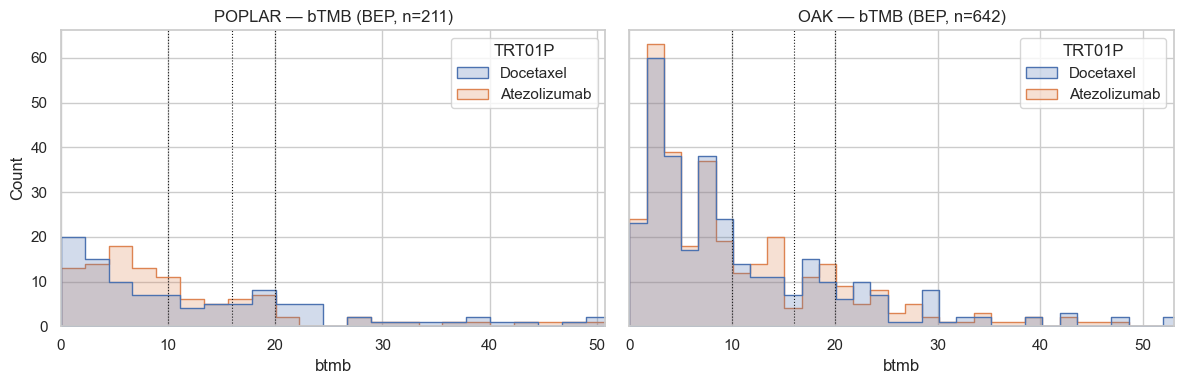

count  mean   std  min  25%  50%   75%   max
Trial  TRT01P                                                    
OAK    Atezolizumab  324.0  10.9  10.7  0.0  3.0  7.5  15.0  67.0
       Docetaxel     318.0  11.1  10.9  0.0  3.0  7.0  16.0  64.0
POPLAR Atezolizumab  105.0  11.2  10.4  1.0  4.0  8.0  15.0  49.0
       Docetaxel     106.0  14.2  15.5  0.0  4.0  9.0  19.8  89.0

In [6]:
bep = clinical[clinical["BEP"] == "Y"].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, trial in zip(axes, ["POPLAR", "OAK"]):
    d = bep[bep["Trial"] == trial]
    sns.histplot(d, x="btmb", hue="TRT01P", bins=40, ax=ax, element="step", stat="count")
    for cut in [10, 16, 20]:
        ax.axvline(cut, color="k", linestyle=":", linewidth=0.8)
    ax.set_title(f"{trial} — bTMB (BEP, n={len(d)})")
    ax.set_xlim(0, d["btmb"].quantile(0.99))
plt.tight_layout()
plt.show()

bep.groupby(["Trial", "TRT01P"])["btmb"].describe().round(1)

## MSAF — maximum somatic allele frequency

MSAF is the highest variant allele fraction observed across the patient's somatic calls. It's a proxy for **ctDNA shedding** — how much tumor-derived DNA is circulating in blood. Low MSAF means low ctDNA, which also means bTMB is called off fewer reads and is noisier. So we expect:

- MSAF has a long right tail (most patients shed little ctDNA)
- MSAF and bTMB are positively correlated (more shedding → more variants detected)
- Very low-MSAF patients are a known bTMB failure mode (sometimes excluded from bTMB subgroup analyses)

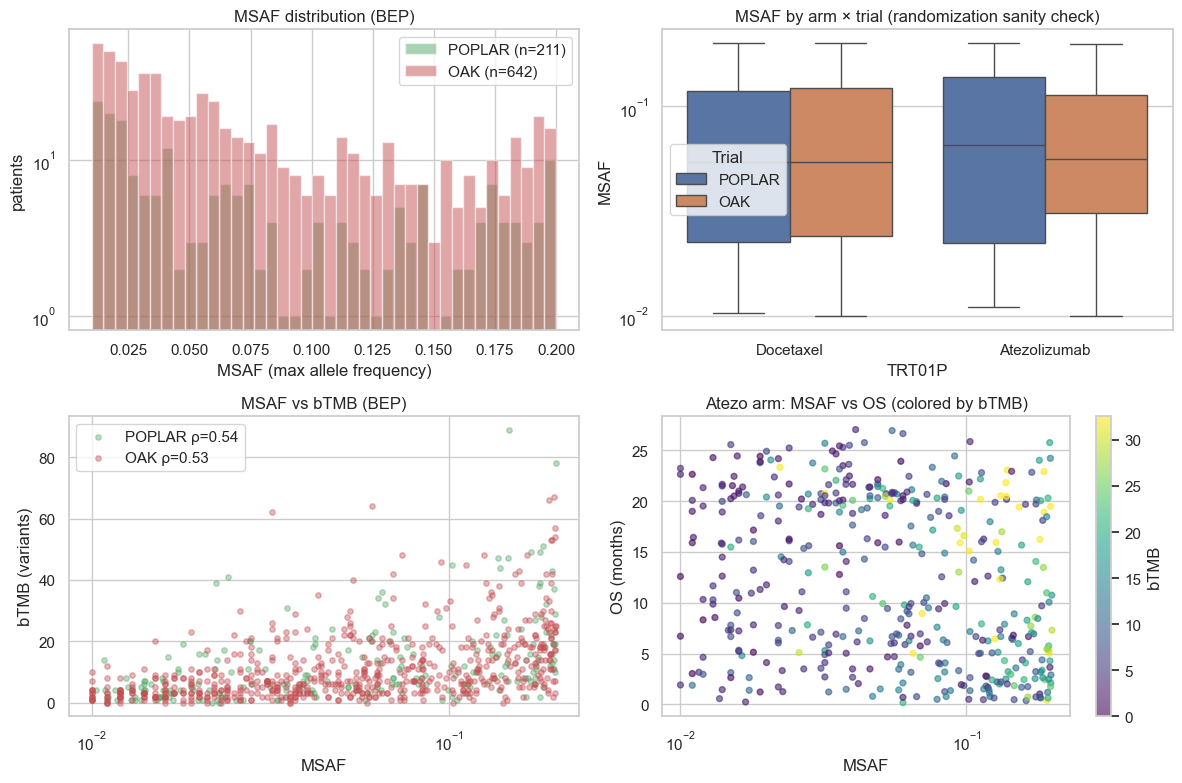

MSAF summary stats (BEP):
        count   mean    std   min    25%    50%    75%  max
Trial                                                      
OAK     642.0  0.075  0.058  0.01  0.026  0.055  0.116  0.2
POPLAR  211.0  0.079  0.063  0.01  0.022  0.061  0.137  0.2


In [7]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (0,0) MSAF distribution per trial, log scale
for trial, color in [('POPLAR','C2'), ('OAK','C3')]:
    d = bep[bep['Trial']==trial]['MSAF'].dropna()
    axes[0,0].hist(d, bins=40, alpha=0.5, label=f'{trial} (n={len(d)})', color=color)
axes[0,0].set_xlabel('MSAF (max allele frequency)')
axes[0,0].set_ylabel('patients')
axes[0,0].set_title('MSAF distribution (BEP)')
axes[0,0].set_yscale('log')
axes[0,0].legend()

# (0,1) MSAF by treatment arm — should be balanced by randomization
sns.boxplot(bep, x='TRT01P', y='MSAF', hue='Trial', ax=axes[0,1])
axes[0,1].set_yscale('log')
axes[0,1].set_title('MSAF by arm × trial (randomization sanity check)')

# (1,0) MSAF vs bTMB — the key relationship
for trial, color in [('POPLAR','C2'), ('OAK','C3')]:
    d = bep[bep['Trial']==trial].dropna(subset=['MSAF','btmb'])
    rho, p = spearmanr(d['MSAF'], d['btmb'])
    axes[1,0].scatter(d['MSAF'], d['btmb'], alpha=0.4, s=15,
                      label=f'{trial} ρ={rho:.2f}', color=color)
axes[1,0].set_xlabel('MSAF')
axes[1,0].set_ylabel('bTMB (variants)')
axes[1,0].set_xscale('log')
axes[1,0].set_title('MSAF vs bTMB (BEP)')
axes[1,0].legend()

# (1,1) MSAF vs OS within atezo arm, color by bTMB
atz = bep[bep['TRT01P']=='Atezolizumab'].dropna(subset=['MSAF','OS','btmb'])
sc = axes[1,1].scatter(atz['MSAF'], atz['OS'], c=atz['btmb'], cmap='viridis',
                       alpha=0.6, s=18, vmax=atz['btmb'].quantile(0.95))
axes[1,1].set_xscale('log')
axes[1,1].set_xlabel('MSAF')
axes[1,1].set_ylabel('OS (months)')
axes[1,1].set_title('Atezo arm: MSAF vs OS (colored by bTMB)')
plt.colorbar(sc, ax=axes[1,1], label='bTMB')

plt.tight_layout()
plt.show()

# Summary
print('MSAF summary stats (BEP):')
print(bep.groupby('Trial')['MSAF'].describe().round(3))

## Kaplan-Meier: OS by treatment arm

Sanity-check against published medians (OAK ITT: atezo 13.8 vs docetaxel 9.6 mo).

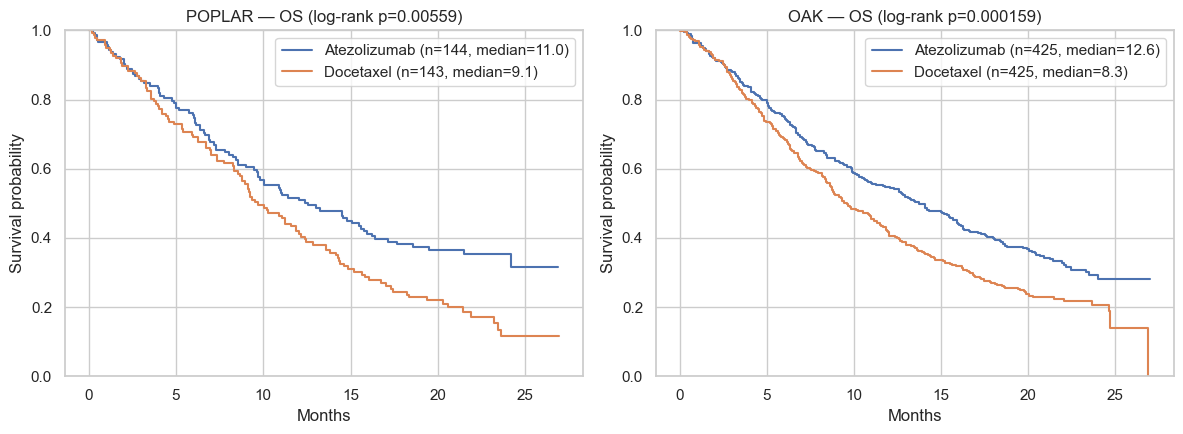

In [8]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, trial in zip(axes, ["POPLAR", "OAK"]):
    d = clinical[clinical["Trial"] == trial].dropna(subset=["OS", "OS.CNSR", "TRT01P"])
    d = d.assign(event=(d["OS.CNSR"] == 0).astype(int))
    for arm, color in [("Atezolizumab", "C0"), ("Docetaxel", "C1")]:
        s = d[d["TRT01P"] == arm]
        kmf = KaplanMeierFitter().fit(s["OS"], s["event"], label=f"{arm} (n={len(s)}, median={s['OS'].median():.1f})")
        kmf.plot_survival_function(ax=ax, ci_show=False, color=color)
    atz = d[d["TRT01P"] == "Atezolizumab"]
    doc = d[d["TRT01P"] == "Docetaxel"]
    lr = logrank_test(atz["OS"], doc["OS"], atz["event"], doc["event"])
    ax.set_title(f"{trial} — OS (log-rank p={lr.p_value:.3g})")
    ax.set_xlabel("Months")
    ax.set_ylabel("Survival probability")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## KM stratified by bTMB ≥ 16 (paper's primary cutoff)

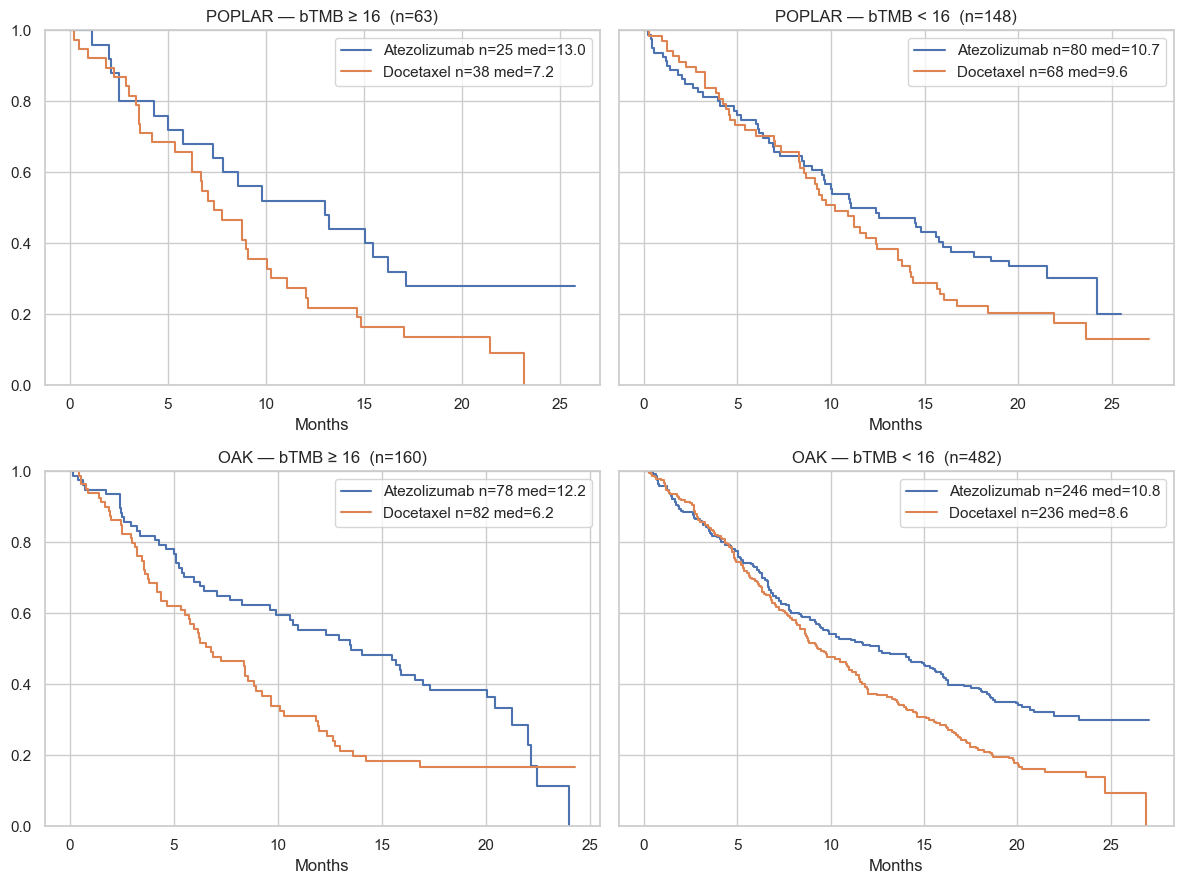

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
for row, trial in enumerate(["POPLAR", "OAK"]):
    d = bep[bep["Trial"] == trial].dropna(subset=["OS", "OS.CNSR", "btmb"]).copy()
    d["event"] = (d["OS.CNSR"] == 0).astype(int)
    for col, (label, mask) in enumerate([("bTMB ≥ 16", d["btmb"] >= 16),
                                         ("bTMB < 16",  d["btmb"] < 16)]):
        ax = axes[row, col]
        sub = d[mask]
        for arm, color in [("Atezolizumab", "C0"), ("Docetaxel", "C1")]:
            s = sub[sub["TRT01P"] == arm]
            if len(s) == 0: continue
            KaplanMeierFitter().fit(s["OS"], s["event"],
                label=f"{arm} n={len(s)} med={s['OS'].median():.1f}"
            ).plot_survival_function(ax=ax, ci_show=False, color=color)
        ax.set_title(f"{trial} — {label}  (n={len(sub)})")
        ax.set_xlabel("Months")
        ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Variant-level data

One row per somatic variant call per patient. Useful for understanding what goes into the bTMB score and looking at per-gene patterns.

In [10]:
print("Columns:", list(variants.columns))
print(f"Total variants: {len(variants):,}")
print(f"Unique patients with variants: {variants['PtID'].nunique()}")
print()
print("Variants per trial:")
print(variants["Study"].value_counts())
print()
print("Variant effect distribution:")
print(variants["effect"].value_counts())

Columns: ['PtID', 'Study', 'chromosome', 'position', 'reference_sequence', 'alternate_sequence', 'status', 'depth', 'af', 'start', 'end', 'gene_name', 'transcript_name', 'cds_syntax', 'protein_syntax', 'effect', 'omitted_driver_mutation']
Total variants: 12,022
Unique patients with variants: 853

Variants per trial:
Study
OAK       8724
POPLAR    3298
Name: count, dtype: int64

Variant effect distribution:
effect
missense      7834
synonymous    2355
nonsense       995
splice         838
Name: count, dtype: int64


In [11]:
# Top recurrently mutated genes (patient-level, any effect)
top_genes = (variants.groupby("gene_name")["PtID"].nunique()
             .sort_values(ascending=False).head(20))
top_genes.to_frame("n_patients_mutated")

,n_patients_mutated
gene_name,
TP53,431
LRP1B,284
DNMT3A,200
FAT3,194
SPTA1,189
KEAP1,119
NF1,116
FAT1,116
MLL2,114


                  btmb  btmb_recomputed
btmb             1.000            0.985
btmb_recomputed  0.985            1.000


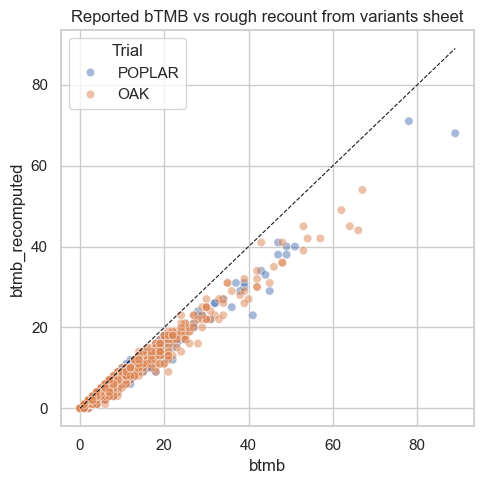

In [12]:
# Sanity check: recompute bTMB from variants and compare to reported btmb
# (Paper's definition filters to non-synonymous, non-driver somatic calls above an AF/depth threshold —
#  a rough approximation here; expect correlation but not exact match.)
rough = (variants[(variants["effect"] != "synonymous") &
                  (variants["omitted_driver_mutation"] != "yes")]
         .groupby("PtID").size().rename("btmb_recomputed"))
check = bep[["PtID", "Trial", "btmb"]].merge(rough, on="PtID", how="left").fillna({"btmb_recomputed": 0})
print(check[["btmb", "btmb_recomputed"]].corr().round(3))

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(check, x="btmb", y="btmb_recomputed", hue="Trial", alpha=0.5, ax=ax)
lim = max(check["btmb"].max(), check["btmb_recomputed"].max())
ax.plot([0, lim], [0, lim], "k--", linewidth=0.8)
ax.set_title("Reported bTMB vs rough recount from variants sheet")
plt.tight_layout()
plt.show()